<a href="https://colab.research.google.com/github/themdanas/diffusion_lm/blob/main/diffusion_llm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setting up the parameters of the model

> Add blockquote



In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
RUN_MODE = "quick"

TRAIN_EXAMPLES = 50_000 # sentances from the dataset
VAL_EXAMPLES = 20_000 #
TOKENIZER_TRAIN_EXAMPLES = 30_000

SEQ_LEN = 256 # cotext length
VOCAB_SIZE = 8_000 #vocablary size

D_MODEL = 384 #embedding dimensions
N_LAYERS = 6 # number of transformer blocks
N_HEADS = 6 # number of multi- head attention
D_FF = 4 * D_MODEL # feed forward  hiddeb layer dimension

DIFFUSION_STEPS = 64 #time steps

#optimzers hyperparameters

TRAIN_STEPS = 20_000
BATCH_SIZE = 32
GRAD_ACCUM = 1 #gradient accumulation
LR = 3e-4 #learning rate
WEIGHT_DECAY = 0.1
WARMUP_STEPS = 200



In [3]:
import os, math, time, json, random
import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader

from datasets import load_dataset


#### Loading the data from hugging face

In [4]:
train_ds = load_dataset("roneneldan/TinyStories", split=f"train[:{TRAIN_EXAMPLES}]")
val_ds   = load_dataset("roneneldan/TinyStories", split=f"validation[:{VAL_EXAMPLES}]")

print(train_ds, val_ds)
print("\nExample:\n", train_ds[0]["text"][:500])

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Dataset({
    features: ['text'],
    num_rows: 50000
}) Dataset({
    features: ['text'],
    num_rows: 20000
})

Example:
 One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them b


In [5]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.normalizers import NFKC
from tokenizers.processors import TemplateProcessing

SPECIAL_TOKENS = [
    "[PAD]","[UNK]","[BOS]", "[EOS]", "[MASK]",
    "<|user|>", "<|system|>", "<|assistant|>", "<|end|>",
]

def tokenizer_training_iterator(ds, n_examples):
  for i in range(min(n_examples, len(ds))):
    story =ds[i]["text"].strip()
    yield f"<|user|>\nWrite a short story.\n<|assistant|>\n{story}\n<|end|>\n"

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.normalizer = NFKC()
tokenizer.pretokenizer = ByteLevel(add_prefix_space=True)

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    min_freuency=2,
    special_tokens=SPECIAL_TOKENS,
)

print("Training tokenizer...")
tokenizer.train_from_iterator(
    tokenizer_training_iterator(train_ds, TOKENIZER_TRAIN_EXAMPLES),
    trainer=trainer
)

bos_id = tokenizer.token_to_id("[BOS]")
eos_id = tokenizer.token_to_id("[EOS]")
tokenizer.post_processor = TemplateProcessing(
    single="[BOS] $A [EOS]",
    special_tokens=[("[BOS]", bos_id), ("[EOS]", eos_id)],
)
tokenizer.deocde = ByteLevelDecoder()

TOKENIZER_DIR = "tokenizer_from_scratch"
os.makedirs(TOKENIZER_DIR, exist_ok=True)
TOKENIZER_FILE = os.path.join(TOKENIZER_DIR, "tokenizer.json")
tokenizer.save(TOKENIZER_FILE)

print(tokenizer.get_vocab_size())
print(tokenizer.encode("Hello, how are you?").tokens)


Training tokenizer...
8000
['[BOS]', 'Hello, ', 'how ', 'are you', '?', '[EOS]']


In [6]:
print("Saved tokenizer to:", TOKENIZER_FILE)
print("Vocab size:", tokenizer.get_vocab_size())

Saved tokenizer to: tokenizer_from_scratch/tokenizer.json
Vocab size: 8000


In [7]:
#!pip install numpy --upgrade
#!pip install transformers --upgrade

In [8]:

from transformers import PreTrainedTokenizerFast

hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=TOKENIZER_FILE
)

hf_tokenizer.pad_token = "[PAD]"
hf_tokenizer.unk_token = "[UNK]"
hf_tokenizer.bos_token = "[BOS]"
hf_tokenizer.eos_token = "[EOS]"
hf_tokenizer.mask_token = "[MASK]"

hf_tokenizer.add_special_tokens({
    "additional_special_tokens": ["<|user|>", "<|system|>", "<|assistant|>", "<|end|>"]
})

PAD_ID = hf_tokenizer.pad_token_id
BOS_ID = hf_tokenizer.bos_token_id
EOS_ID = hf_tokenizer.eos_token_id
MASK_ID = hf_tokenizer.mask_token_id

print("PAD_ID:", PAD_ID, "BOS_ID:", BOS_ID, "EOS_ID:", EOS_ID, "MASK_ID:", MASK_ID)
print("Example encoding:", hf_tokenizer.encode("Hello, how are you?")[:20])

PAD_ID: 0 BOS_ID: 2 EOS_ID: 3 MASK_ID: 4
Example encoding: [2, 1949, 680, 5054, 39, 3]


## Build a tiny diffusion LM(Transformer) from scrach

In [9]:
from dataclasses import dataclass

@dataclass

class DiffusionLMConfig:
    vocab_size: int
    seq_len: int
    d_model: int
    n_heads: int
    n_layers: int
    d_ff: int
    dropout: float
    diffusion_steps: int




class DiffusionTransformer(nn.Module):
    def __init__(self, cfg: DiffusionLMConfig):
        super().__init__()
        self.cfg = cfg

        self.token_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.seq_len, cfg.d_model)
        self.time_emb = nn.Embedding(DIFFUSION_STEPS + 1, cfg.d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model,
            nhead=cfg.n_heads,
            dim_feedforward=cfg.d_ff,
            dropout=cfg.dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(enc_layer,num_layers=cfg.n_layers)
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

        #Tie weights
        self.lm_head.weight = self.token_emb.weight

        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, input_ds, timesteps, attention_mask=None):
        #input_ids: [B,L]
        #timesteps = [B] interger diffusion step in [1...T]
        #attention_mask = [B,L] bool, True for non-pad tokens

        B, L = input_ds.shape
        if L> self.cfg.seq_len:
          raise ValueError(f"Sequence length {L} > cfg.seq_len {self.cfg.seq_len}")

        pos = torch.arange(L, device=input_ds.device).unsqueeze(0) # [1,L]
        x= self.token_emb(input_ds) + self.pos_emb(pos)

        t_emb = self.time_emb(timesteps).unsqueeze(1) # [B,1] to broadcast across L
        x = x + t_emb
        x = self.drop(x)

        if attention_mask is None:
          src_key_padding_mask = None
        else:
          src_key_padding_mask = ~attention_mask.bool()

        x = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        x = self.ln_f(x) #layer normalization
        logits = self.lm_head(x)
        return logits

cfg = DiffusionLMConfig(
    vocab_size=len(hf_tokenizer),
    seq_len=SEQ_LEN,
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    d_ff=D_FF,
    dropout=0.1,
    diffusion_steps=DIFFUSION_STEPS,
)

model = DiffusionTransformer(cfg)

n_param = sum(p.numel() for p in model.parameters())
print(f"Number of model parameters: {n_param/1e6:.2f}M")

Number of model parameters: 13.84M


/tmp/ipykernel_2579/3413673984.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer,num_layers=cfg.n_layers)


## Creating the Token Block dataset (for language modeling)

### We convert each story into like a chat like format

In [10]:
def format_as_chat(story_text: str) -> str:
  story_text = story_text.strip()
  return f"<|user|>\nWrite a short story.\n<|assistant|>{story_text}\n<|end|>\n"

class TokenBlockDataset(IterableDataset):
  def __init__(self, hf_ds, tokenizer, seq_len,shuffle=False, seed=0):
    self.hf_ds = hf_ds
    self.tokenizer = tokenizer
    self.seq_len = seq_len
    self.shuffle = shuffle
    self.seed = seed

  def __iter__(self):
    indices = list(range(len(self.hf_ds)))
    if self.shuffle:
      rng = random.Random(self.seed)
      rng.shuffle(indices)

    buffer = []
    for idx in indices:
      text = format_as_chat(self.hf_ds[idx]["text"])
      ids = self.tokenizer.encode(text, add_special_tokens=True)
      buffer.extend(ids)

      while len(buffer) >= self.seq_len:
        block = buffer[:self.seq_len]
        buffer = buffer[self.seq_len:]
        yield torch.tensor(block, dtype=torch.long)

train_block = TokenBlockDataset(train_ds, hf_tokenizer, SEQ_LEN, shuffle=True, seed=42)
val_block = TokenBlockDataset(val_ds, hf_tokenizer, SEQ_LEN, shuffle=False)

def collate_blocks(batch):
  input_ids =torch.stack(batch, dim=0)
  attention_mask = (input_ids != PAD_ID)
  return {"input_ids": input_ids, "attention_mask": attention_mask}

train_loader = DataLoader(train_block, batch_size=BATCH_SIZE, collate_fn=collate_blocks)
val_loader = DataLoader(val_block, batch_size=BATCH_SIZE, collate_fn=collate_blocks)

b = next(iter(train_loader))

print("Decoded snippet:\n", hf_tokenizer.decode(b["input_ids"][0][:120].tolist()))
print({k: v.shape for k, v in b.items()})

Decoded snippet:
 [BOS] <|user|> 
 W rite a short s tory .
 <|assistant|> There  was  on c e a  little  fish  who lived  in the  deep  blue  sea . She  swam  around and  sang  with the  fish and  shar k s. But  one day,  something  chang ed :  the  water  was  growing  dark er. The  fish  couldn't s ee  very  far  and  soon  she  grew  scared .

She  swam  up to the  sur face  to  look  around,  but s omething  still  felt  wrong . There  was  no  o x y g en  in the air  and the  sun  felt  har sh . Suddenly,  a big  cloud  appear ed and the  water  got  even  dark er .

The little  fish  was scared and  asked the  cloud  " Why are you  here ?" . The  cloud  replied  in a  har sh  whisper : " I' ve  come to  take  away the  o x y g en . All the  water  creature s  need to  leave
{'input_ids': torch.Size([32, 256]), 'attention_mask': torch.Size([32, 256])}


# Diffusion Curruption (Masking) + training loss

In [11]:
def mask_ratio_schedule(t,T: int):
  #Linear schedule: ratio = t/T
  return t.float()/ float(T)

@torch.no_grad()
def corrupt_with_mask(input_ids, attention_mask, t, mask_token_id:int, T:int):
  #Return noisy_ids lables, mask_positives
  B, L = input_ids.shape
  ratio = mask_ratio_schedule(t,T).unsqueeze(1)

  can_mask = attention_mask.clone()
  can_mask &= (input_ids != BOS_ID) & (input_ids != EOS_ID) & (input_ids != PAD_ID)

  rand = torch.rand((B,L), device=input_ids.device)
  mask_positions = (rand<ratio) & can_mask

  noisy = input_ids.clone()
  noisy[mask_positions] = mask_token_id

  labels = torch.full_like(input_ids, -100)
  labels[mask_positions] = input_ids[mask_positions]

  return noisy, labels, mask_positions

def diffusion_loss(model,batch, T:int):
  input_ids = batch["input_ids"]
  attention_mask = batch["attention_mask"]

  B = input_ids.size(0)
  t = torch.randint(1, T+1, (B,), device=input_ids.device)

  noisy_ids, labels, _ = corrupt_with_mask(
      input_ids=input_ids,
      attention_mask=attention_mask,
      t=t,
      mask_token_id=MASK_ID,
      T=T,
  )

  logits = model(noisy_ids, timesteps=t, attention_mask=attention_mask)
  loss = F.cross_entropy(
      logits.view(-1, logits.size(-1)),
      labels.view(-1),
      ignore_index=-100,
  )
  return loss

In [12]:
from accelerate import Accelerator
from transformers import get_cosine_schedule_with_warmup

accelerator = Accelerator(mixed_precision="fp16")
device = accelerator.device

model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TRAIN_STEPS,
)

model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
    model, optimizer, train_loader, val_loader, scheduler
)

def eval_loss(n_batches=20):
  model.eval()
  losses = []
  with torch.no_grad():
    for i, batch in enumerate(val_loader):
      if i >= n_batches:
        break

      loss = diffusion_loss(model, batch, T=cfg.diffusion_steps)

      # gather across processs -> always make it 1D
      gathered = accelerator.gather(loss.detach().float().reshape(1))

      #now gathered is shape [world_size, 1 on singlr gpu]
      losses.append(gathered.cpu())


  model.train()

  if len(losses) == 0:
    return float("nan")

  losses = torch.cat(losses)
  return losses.mean().item()

model.train()
pbar = tqdm(range(TRAIN_STEPS), disable=not accelerator.is_main_process)
running = []

train_iter = iter(train_loader)

for step in pbar:
  try:
    batch =next(train_iter)

  except StopIteration:
    train_iter = iter(train_loader)
    batch = next(train_iter)

  loss = diffusion_loss(model, batch, T=cfg.diffusion_steps)/GRAD_ACCUM
  accelerator.backward(loss)


  if (step +1) % GRAD_ACCUM == 0:
    accelerator.clip_grad_norm_(model.parameters(),1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  if (step+1) % 10 == 0 and accelerator.is_main_process:
    pbar.set_description(f"loss={np.mean(running[-50:]):.4f} lr={scheduler.get_last_lr()[0]:.2e}")

  if (step+1) % 100 == 0 and accelerator.is_main_process:
    val_l = eval_loss(n_batches=10)
    print(f"step={step+1} val_loss={val_l:.4f}")



  0%|          | 0/20000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


step=100 val_loss=30.0987
step=200 val_loss=17.7257
step=300 val_loss=11.5680
step=400 val_loss=9.5355
step=500 val_loss=8.8040
step=600 val_loss=8.4615
step=700 val_loss=8.3099
step=800 val_loss=8.2253
step=900 val_loss=8.1812
step=1000 val_loss=8.1487
step=1100 val_loss=8.1247
step=1200 val_loss=8.1205
step=1300 val_loss=8.1076
step=1400 val_loss=8.1044
step=1500 val_loss=8.0905
step=1600 val_loss=8.0747
step=1700 val_loss=8.1036
step=1800 val_loss=8.0736
step=1900 val_loss=8.0860
step=2000 val_loss=8.0885
step=2100 val_loss=8.0746
step=2200 val_loss=8.0856
step=2300 val_loss=8.0766
step=2400 val_loss=8.0896
step=2500 val_loss=8.0713
step=2600 val_loss=8.0800
step=2700 val_loss=8.0709
step=2800 val_loss=8.0726
step=2900 val_loss=8.0579
step=3000 val_loss=8.0690
step=3100 val_loss=8.0622
step=3200 val_loss=8.0553
step=3300 val_loss=8.0447
step=3400 val_loss=8.0517
step=3500 val_loss=8.0514
step=3600 val_loss=8.0441
step=3700 val_loss=8.0580
step=3800 val_loss=8.0559
step=3900 val_loss

In [13]:
if accelerator.is_main_process:
  OUT_DIR = "checkpoints/final"
  os.makedirs(OUT_DIR, exist_ok=True)
  torch.save(accelerator.unwrap_model(model).state_dict(), os.path.join(OUT_DIR, "model.pt"))
  with open(os.path.join(OUT_DIR, "config.json"),"w") as f:
    json.dump(cfg.__dict__, f, indent=2)

  hf_tokenizer.save_pretrained(os.path.join(OUT_DIR, "tokenizer"))
  print("Saved final checkpoint to:", OUT_DIR)

Saved final checkpoint to: checkpoints/final


In [14]:
@torch.no_grad()
def diffusion_generate(
    model,
    tokenizer,
    prompt_text:str,
    max_new_tokens: int=128,
    diffusion_steps: int = 64,
    temperature: float=1.0,
    top_k: int=0,
    record_steps: bool = True,
):

    model.eval()
    device = next(model.parameters()).device

    prompt_ids = tokenizer.encode(prompt_text,add_special_tokens=True)
    prompt_ids = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0)

    Lp = prompt_ids.size(1)
    L = min(cfg.seq_len, Lp + max_new_tokens)
    gen_len = L - Lp

    x = torch.full((1, L), MASK_ID, dtype=torch.long, device=device)
    x[:, :Lp] = prompt_ids[:, :Lp]


    fixed = torch.zeros((1,L), dtype=torch.bool, device=device)
    fixed[:, :Lp] = True

    attention_mask = torch.ones((1,L), dtype=torch.bool, device=device)

    frames =[]

    def sample_from_logits(logits):
      if temperature != 1.0:
        logists = logits / temperature

      if top_k and top_k>0:
        topk_vals, topk_idx = torch.topk(logits, k=top_k, dim=-1)
        filtered = torch.full_like(logits, float("-inf"))
        filtered.scatter_(-1, topk_idx, topk_vals)
        logits = filtered

      probs = F.softmax(logits, dim=-1)
      flat = probs.view(-1, probs.size(-1))
      sampled = torch.multinomial(flat, num_samples=1).view(1,L)
      sampled_prob = probs.gather(-1, sampled.unsqueeze(-1)).squeeze(-1)
      return sampled, sampled_prob

    for s in range(diffusion_steps, 0, -1):
      t = torch.tensor([s], dtype=torch.long, device=device)
      logits = model(x, timesteps=t, attention_mask=attention_mask)
      sampled, conf = sample_from_logits(logits)

      update_pos = ~fixed
      x[update_pos] = sampled[update_pos]

      next_ratio = float(s-1)/float(diffusion_steps)
      target_masks = int(math.ceil(gen_len * next_ratio))

      gen_positions = torch.arange(L, device=device) >= Lp
      candidates = gen_positions & (~fixed[0])
      cand_idx = torch.where(candidates)[0]

      if target_masks > 0 and cand_idx.numel()>0:
        cand_conf = conf[0, cand_idx]
        k = min(target_masks, cand_idx.numel())
        _, low_idx = torch.topk(cand_conf, k=k, largest=False)
        remask_positions = cand_idx[low_idx]
        x[0, remask_positions] = MASK_ID

      if record_steps:
        decoded = tokenizer.decode(x[0].tolist())
        decoded = decoded.replace("[MASK]","█")
        frames.append((s,decoded))

    final = tokenizer.decode(x[0].tolist())
    model.train()
    return final, frames

def chat_prompt(user_msg: str, system_msg: str = None) -> str:
  parts =[]
  if system_msg:
    parts.append(f"<|system|>\n{system_msg}\n")

  parts.append(f"<|user|>\n{user_msg}\n")
  parts.append(f"<|assistant|>\n")
  return "".join(parts)

TEST_USER_PROMPT = "One upon a time"
prompt_text = chat_prompt(TEST_USER_PROMPT)

final_text, frames = diffusion_generate(
    model=accelerator.unwrap_model(model),
    tokenizer=hf_tokenizer,
    prompt_text=prompt_text,
    max_new_tokens=128,
    diffusion_steps=cfg.diffusion_steps,
    temperature=1.0,
    top_k=50,
    record_steps=True,
)

print("Final decoded (raw):\n")
print(final_text[:1000])
print("\nRecorded frames:", len(frames))

Final decoded (raw):

[BOS] <|user|> 
 One  upon a tim e 
 <|assistant|> 
 [EOS] .
 .
 W rite a short s <|assistant|> .
 .
 Once  Once  Tim. Tim  there was a  e,  little girl named  loved to play outside  Lily. She  loved to  s. One day,  loved to  .  and  . He  and  and  e . He  to  his  he  .

 she  had  s . The  it  s  Lily  . She  . She  ed  and  !  his  had  was  a  ,  Lily  of  that  . She  . She  s and  her  it his  .  . He  e  so  it you  . She  .

 .

 was  ed ,  so  on the  he  said, " on the  s and  !  .

The  s was  she  .

 .

 . He  s  's  ,  he  the  was  his  s and  a  Lily  it had  . She  in the  ing  he  the  s  ing  so  s and  s  started to  started to  .

 her  in the  his  it s  her  s  it  had  y . He  's  the  very  . He  to  was  e the  s  's  s and 

Recorded frames: 64


In [15]:
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio

def get_mono_font(size=20):
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
    ]
    for path in candidates:
        if os.path.exists(path):
            return ImageFont.truetype(path, size=size)
    return ImageFont.load_default()

def render_terminal_frame(lines, width=1200, height=700, font_size=20, margin=20, line_spacing=6):
    bg = (10, 10, 10)
    fg = (230, 230, 230)

    img = Image.new("RGB", (width, height), bg)
    draw = ImageDraw.Draw(img)
    font = get_mono_font(font_size)

    y = margin
    for line in lines:
        draw.text((margin, y), line, font=font, fill=fg)
        y += font_size + line_spacing
        if y > height - margin:
            break
    return img

def wrap_text_to_width(text, max_chars=90):
    out = []
    for paragraph in text.split("\n"):
        paragraph = paragraph.rstrip()
        if not paragraph:
            out.append("")
            continue
        while len(paragraph) > max_chars:
            out.append(paragraph[:max_chars])
            paragraph = paragraph[max_chars:]
        out.append(paragraph)
    return out

def make_chat_lines(user_msg: str, assistant_text: str):
    header = "============================== multi-turn chat mode ==============================="
    sub = "<Starting a new chat. Type your message.>"
    lines = [header, sub, ""]
    lines += ["[You]:", user_msg, ""]
    lines += ["[Assistant]:"]

    if "<|assistant|>" in assistant_text:
        assistant_text = assistant_text.split("<|assistant|>", 1)[1]
    assistant_text = assistant_text.replace("<|end|>", "").strip()

    lines += wrap_text_to_width(assistant_text, max_chars=90)
    return lines

gif_frames = []
for (s, decoded) in frames:
    lines = make_chat_lines(TEST_USER_PROMPT, decoded)
    lines.insert(2, f"(diffusion step {s:03d}/{cfg.diffusion_steps:03d})")
    img = render_terminal_frame(lines)
    gif_frames.append(np.array(img))

GIF_PATH = "inference.gif"
imageio.mimsave(GIF_PATH, gif_frames, duration=0.08)

print("Saved:", GIF_PATH)

Saved: inference.gif


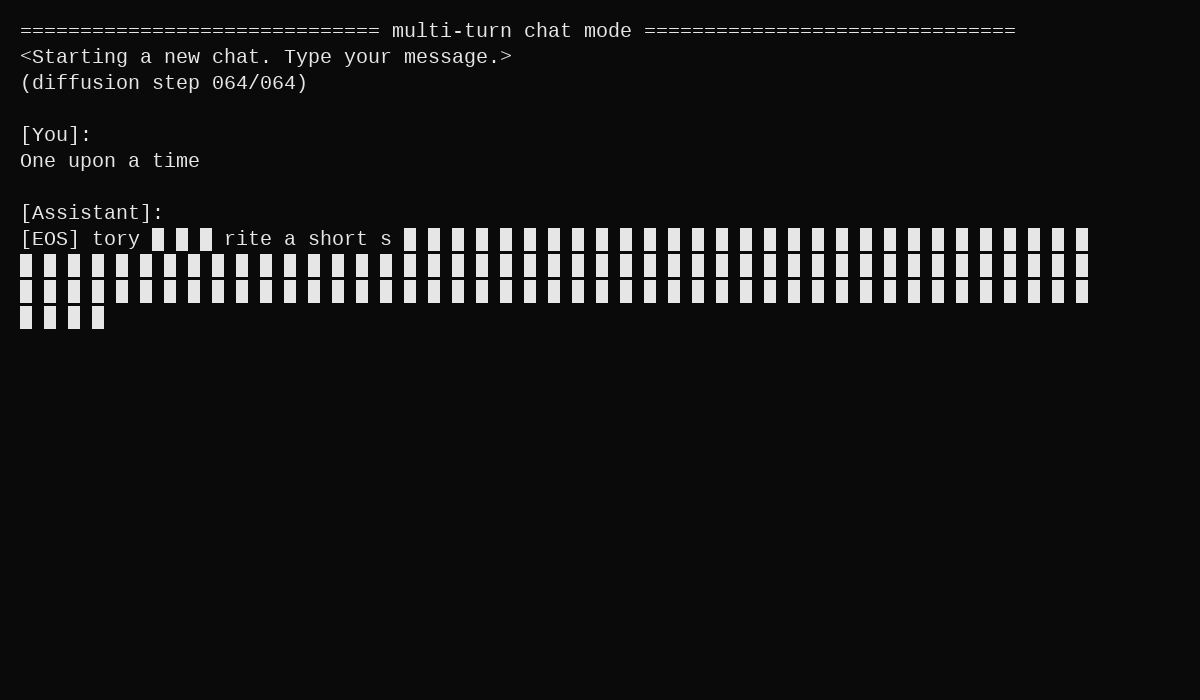

In [16]:
from IPython.display import Image as IPyImage, display
display(IPyImage(filename="inference.gif"))

In [17]:
import os
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio

def get_mono_font(size=20):
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
    ]
    for path in candidates:
        if os.path.exists(path):
            return ImageFont.truetype(path, size=size)
    return ImageFont.load_default()

def render_terminal_frame(lines, width=1200, height=700, font_size=20, margin=20, line_spacing=6):
    # === NEON COLORS ===
    cyan = (0, 255, 255)
    magenta = (255, 0, 255)
    neon_green = (57, 255, 20)
    orange = (255, 165, 0)
    dim = (80, 80, 100)
    text_color = (200, 200, 220)

    # Gradient background
    img = Image.new("RGB", (width, height))
    pixels = img.load()
    for py in range(height):
        t = py / height
        r = int(12 * (1-t) + 4 * t)
        g = int(12 * (1-t) + 4 * t)
        b = int(28 * (1-t) + 12 * t)
        for px in range(width):
            pixels[px, py] = (r, g, b)

    draw = ImageDraw.Draw(img)
    font = get_mono_font(font_size)
    font_small = get_mono_font(font_size - 4)

    # === CORNER BRACKETS ===
    cs = 25
    draw.line([(6, 6+cs), (6, 6), (6+cs, 6)], fill=cyan, width=2)
    draw.line([(width-6-cs, 6), (width-6, 6), (width-6, 6+cs)], fill=cyan, width=2)
    draw.line([(6, height-6-cs), (6, height-6), (6+cs, height-6)], fill=magenta, width=2)
    draw.line([(width-6-cs, height-6), (width-6, height-6), (width-6, height-6-cs)], fill=magenta, width=2)

    # === PARSE LINES FOR STEP INFO ===
    step_current, step_total = None, None
    for line in lines:
        if "diffusion step" in line.lower():
            import re
            match = re.search(r'(\d+)/(\d+)', line)
            if match:
                step_current, step_total = int(match.group(1)), int(match.group(2))
                break

    y = margin

    for i, line in enumerate(lines):
        if "====" in line:
            # Header panel
            header_text = line.replace("=", "").strip() or "◈ DIFFUSION LANGUAGE MODEL ◈"
            draw.rounded_rectangle([margin, y-2, width-margin, y+font_size+8],
                                  radius=5, fill=(15, 15, 30), outline=cyan, width=2)
            draw.line([(margin+10, y), (width-margin-10, y)], fill=cyan, width=1)
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    draw.text((margin + 15 + dx, y + 3 + dy), header_text, font=font, fill=(0, 80, 80))
            draw.text((margin + 15, y + 3), header_text, font=font, fill=cyan)
            y += font_size + line_spacing + 8

        elif "diffusion step" in line.lower() and step_current is not None:
            # Progress bar
            progress = step_current / step_total
            bar_x, bar_y = margin, y
            bar_w, bar_h = width - margin*2 - 200, 20

            draw.rounded_rectangle([bar_x, bar_y, bar_x+bar_w, bar_y+bar_h],
                                  radius=bar_h//2, fill=(20, 20, 35), outline=dim, width=1)

            seg_w, gap = 8, 3
            num_segs = (bar_w - 6) // (seg_w + gap)
            filled = int(num_segs * progress)

            for si in range(num_segs):
                sx = bar_x + 3 + si * (seg_w + gap)
                if si < filled:
                    t = si / max(num_segs - 1, 1)
                    seg_color = (int(cyan[0]*(1-t) + magenta[0]*t),
                                int(cyan[1]*(1-t) + magenta[1]*t),
                                int(cyan[2]*(1-t) + magenta[2]*t))
                else:
                    seg_color = (25, 25, 40)
                draw.rounded_rectangle([sx, bar_y+3, sx+seg_w, bar_y+bar_h-3], radius=2, fill=seg_color)

            step_text = f"STEP {step_current:03d}/{step_total:03d}"
            tx = width - margin - 180
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    draw.text((tx+dx, bar_y+dy), step_text, font=font_small, fill=(80, 50, 0))
            draw.text((tx, bar_y), step_text, font=font_small, fill=orange)
            y += bar_h + line_spacing + 5

        elif line.startswith("[You]:"):
            draw.text((margin, y), "▶ USER", font=font_small, fill=dim)
            y += font_size + line_spacing

        elif line.startswith("[Assistant]:"):
            draw.text((margin, y), "◀ ASSISTANT", font=font_small, fill=dim)
            y += font_size + line_spacing

        elif "<Starting a new chat" in line:
            draw.text((margin, y), line, font=font_small, fill=dim)
            y += font_size + line_spacing

        elif line.strip() == "":
            y += line_spacing

        else:
            in_user = False
            in_assistant = False
            for prev_line in lines[:i]:
                if "[You]:" in prev_line:
                    in_user, in_assistant = True, False
                elif "[Assistant]:" in prev_line:
                    in_user, in_assistant = False, True

            if in_user:
                color, glow = cyan, (0, 60, 60)
            elif in_assistant:
                color, glow = neon_green, (15, 60, 5)
            else:
                color, glow = text_color, None

            if glow:
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx != 0 or dy != 0:
                            draw.text((margin + dx, y + dy), line, font=font, fill=glow)
            draw.text((margin, y), line, font=font, fill=color)
            y += font_size + line_spacing

        if y > height - margin:
            break

    # Scanlines
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    scanline_draw = ImageDraw.Draw(overlay)
    for sy in range(0, height, 2):
        scanline_draw.line([(0, sy), (width, sy)], fill=(0, 0, 0, 12))
    img = Image.alpha_composite(img.convert("RGBA"), overlay).convert("RGB")

    return img

def wrap_text_to_width(text, max_chars=90):
    out = []
    for paragraph in text.split("\n"):
        paragraph = paragraph.rstrip()
        if not paragraph:
            out.append("")
            continue
        while len(paragraph) > max_chars:
            out.append(paragraph[:max_chars])
            paragraph = paragraph[max_chars:]
        out.append(paragraph)
    return out

def make_chat_lines(user_msg: str, assistant_text: str):
    header = "============================== multi-turn chat mode ==============================="
    sub = "<Starting a new chat. Type your message.>"
    lines = [header, sub, ""]
    lines += ["[You]:", user_msg, ""]
    lines += ["[Assistant]:"]
    if "<|assistant|>" in assistant_text:
        assistant_text = assistant_text.split("<|assistant|>", 1)[1]
    assistant_text = assistant_text.replace("<|end|>", "").strip()
    lines += wrap_text_to_width(assistant_text, max_chars=90)
    return lines

# === DEMO ===
if __name__ == "__main__":
    TEST_USER_PROMPT = "Explain how diffusion models work."
    class cfg:
        diffusion_steps = 50

    final = "Diffusion models work by gradually adding noise to data during training, then learning to reverse this process. During generation, they start with pure noise and iteratively denoise it step by step, eventually producing coherent output like images or text."

    frames = []
    for s in range(1, cfg.diffusion_steps + 1):
        p = s / cfg.diffusion_steps
        if p < 0.4:
            decoded = "".join([chr(np.random.randint(33, 127)) if np.random.random() > 0.25 else ' ' for _ in range(len(final))])
        elif p < 0.75:
            chars = list(final)
            for i in range(len(chars)):
                if np.random.random() > p and chars[i] not in ' ':
                    chars[i] = chr(np.random.randint(97, 123))
            decoded = "".join(chars)
        else:
            chars = list(final)
            for i in range(len(chars)):
                if np.random.random() > p * 1.2 and chars[i] not in ' ':
                    chars[i] = chr(np.random.randint(97, 123))
            decoded = "".join(chars)
        frames.append((s, decoded))

    gif_frames = []
    for (s, decoded) in frames:
        lines = make_chat_lines(TEST_USER_PROMPT, decoded)
        lines.insert(2, f"(diffusion step {s:03d}/{cfg.diffusion_steps:03d})")
        img = render_terminal_frame(lines)
        gif_frames.append(np.array(img))
    GIF_PATH = "inference_cool.gif"
    imageio.mimsave(GIF_PATH, gif_frames, duration=0.08)
    print("Saved:", GIF_PATH)

Saved: inference_cool.gif


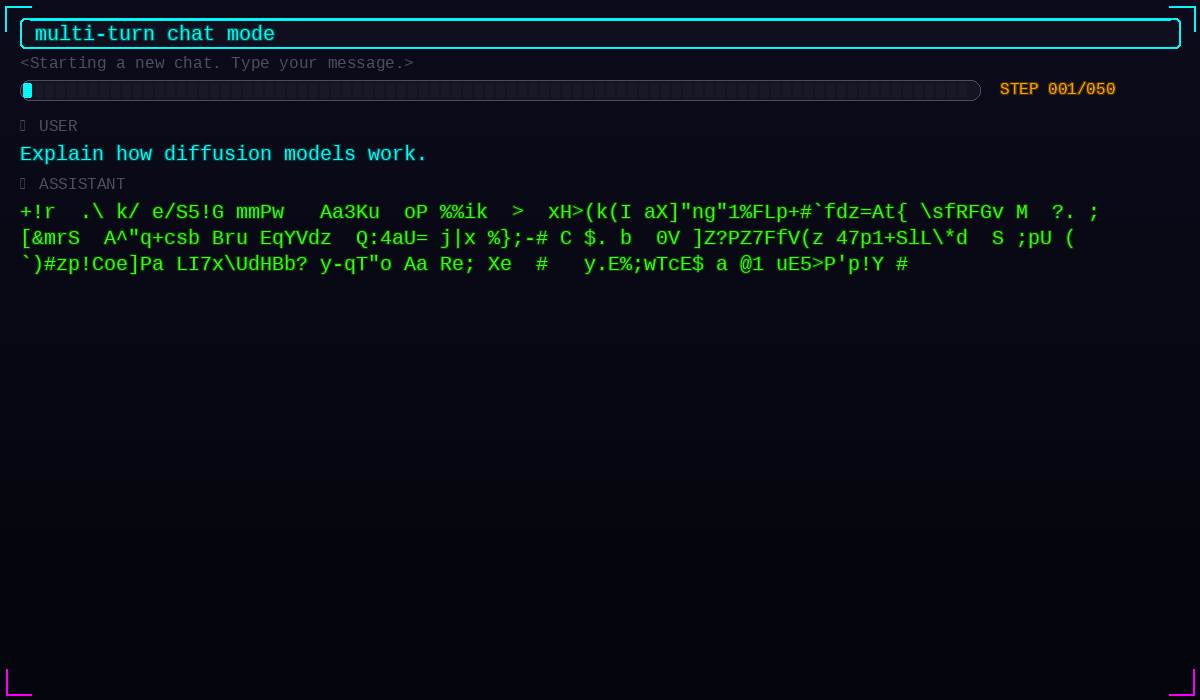

In [18]:
from IPython.display import Image as IPyImage, display
display(IPyImage(filename="inference_cool.gif"))